## NOMBRE: DANIEL ISMAEL FLORES ESPÍN
## ASIGNATURA: RECUPERACIÓN DE INFORMACIÓN

# Ejercicio 5: Espacio Vectorial

## Objetivo de la práctica
- Implementar un Sistema de Recuperación de Información completo, desde la lectura del corpus hasta la recuperación de resultados.

## Parte 0: Carga del Corpus

Vamos a utilizar la API de Kaggle para acceder al dataset _Wikipedia Text Corpus for NLP and LLM Projects_

El corpus está disponible desde este [link](https://www.kaggle.com/datasets/gzdekzlkaya/wikipedia-text-corpus-for-nlp-and-llm-projects?utm_source=chatgpt.com)

### Actividad

1. Carga el corpus
2. Realiza las etapas de preprocesamiento sobre el corpus


In [1]:
import os

if not os.path.exists("wikipedia"):
    os.makedirs("wikipedia", exist_ok=True)
    !kaggle datasets download \
        -d gzdekzlkaya/wikipedia-text-corpus-for-nlp-and-llm-projects \
        -p wikipedia --unzip --quiet
    print("Dataset descargado.")
else:
    print("Dataset ya existe localmente.")

Dataset URL: https://www.kaggle.com/datasets/gzdekzlkaya/wikipedia-text-corpus-for-nlp-and-llm-projectsDataset descargado.

License(s): CC-BY-SA-4.0


In [2]:
import pandas as pd

# Cargamos el CSV completo — sin samplear, usamos los 10,859 documentos
df = pd.read_csv("wikipedia/wikipedia_text_corpus.csv")

# La columna "text" tiene: primera línea = título, resto = cuerpo del artículo
# split("\n\n", n=1) divide solo en la PRIMERA ocurrencia de doble salto de línea
# expand=True convierte el resultado en dos columnas separadas
df[["titulo", "cuerpo"]] = df["text"].str.split("\n\n", n=1, expand=True)

# Eliminamos columnas que no necesitamos
df = df.drop(columns=["Unnamed: 0", "text"]).reset_index(drop=True)

print(f"Documentos cargados: {len(df)}")
df.head(3)

Documentos cargados: 10859


,titulo,cuerpo
0,Anovo,Anovo (formerly A Novo) is a computer services...
1,Battery indicator,A battery indicator (also known as a battery g...
2,Bob Pease,"Robert Allen Pease (August 22, 1940Â â€“ June ..."


In [3]:
import string
import nltk
nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

STOPWORDS  = set(stopwords.words("english"))  # palabras vacías en inglés
PUNTUACION = set(string.punctuation)          # signos de puntuación
stemmer    = PorterStemmer()                  # algoritmo de Porter para stemming


def preprocesar(texto):
    """
    Pipeline de preprocesamiento:
      1. Verificar que sea string (guard contra NaN)
      2. Minúsculas
      3. Tokenizar (split por espacios)
      4. Limpiar puntuación al inicio/final de cada token
      5. Filtrar stopwords y tokens vacíos
      6. Aplicar stemming de Porter
    Retorna: lista de tokens preprocesados
    """
    # Guard: si el texto no es string (NaN, float), retornamos lista vacía
    if not isinstance(texto, str):
        return []

    # Paso 1: todo a minúsculas, luego split por espacios
    tokens = texto.lower().split()

    # Paso 2: strip() elimina puntuación pegada al inicio/fin del token
    # ej. "learning," -> "learning" | "(computer" -> "computer"
    tokens = [t.strip(string.punctuation) for t in tokens]

    # Paso 3: filtrar tokens vacíos, stopwords y signos sueltos
    tokens = [
        t for t in tokens
        if t and t not in STOPWORDS and t not in PUNTUACION
    ]

    # Paso 4: stemming — reduce cada token a su raíz
    # ej. "running" -> "run" | "algorithms" -> "algorithm"
    tokens = [stemmer.stem(t) for t in tokens]

    return tokens


# df["tokens"]       : lista de tokens (para BM25)
# df["texto_limpio"] : string de tokens unidos (para TF-IDF, que espera strings)
df["tokens"]       = df["cuerpo"].apply(preprocesar)
df["texto_limpio"] = df["tokens"].apply(lambda t: " ".join(t))

df[["titulo", "tokens"]].head(3)

,titulo,tokens
0,Anovo,"[anovo, formerli, novo, comput, servic, compan..."
1,Battery indicator,"[batteri, indic, also, known, batteri, gaug, d..."
2,Bob Pease,"[robert, allen, peas, august, 22, 1940â, â€“, ..."


## Parte 1: Recuperación con TF-IDF

### Actividad:
3. Obtén la representación vectorial de los documentos utilizando el modelo TF-IDF
4. A partir de un conjunto de 10 queries, verifica la recuperación del sistema

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TfidfVectorizer construye la matriz TF-IDF como sparse matrix
# sparse matrix: solo almacena los valores != 0, ahorra memoria
# (la matriz completa sería 10,859 docs x ~179k términos)

# tokenizer=lambda x: x.split() : usamos nuestros tokens ya procesados
# token_pattern=None             : desactivamos el tokenizador interno de sklearn
vectorizer   = TfidfVectorizer(tokenizer=lambda x: x.split(), token_pattern=None)

# fit_transform: aprende el vocabulario Y calcula la matriz en un solo paso
# Resultado shape: (n_docs, n_términos)
tfidf_matrix = vectorizer.fit_transform(df["texto_limpio"])

print(f"Dimensiones matriz TF-IDF: {tfidf_matrix.shape}")

Dimensiones matriz TF-IDF: (10859, 179280)


In [5]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity


def buscar_tfidf(query, top_k=5):
    """
    Recupera los top_k documentos más similares a la query usando TF-IDF.
    Retorna un DataFrame con columnas: rank, titulo, score.
    """
    # Preprocesamos la query con el MISMO pipeline que los documentos
    tokens_query = preprocesar(query)
    texto_query  = " ".join(tokens_query)

    # transform: convierte la query en vector usando el vocabulario ya aprendido
    # (solo .transform, NO .fit_transform — no queremos modificar el vocabulario)
    query_vec = vectorizer.transform([texto_query])

    # cosine_similarity: producto punto normalizado entre query y cada documento
    # Resultado shape: (1, n_docs) -> .flatten() lo convierte en array 1D
    similitudes = cosine_similarity(query_vec, tfidf_matrix).flatten()

    # argsort() devuelve índices de menor a mayor
    # [::-1] invierte (mayor a menor) -> [:top_k] toma los primeros k
    top_indices = np.argsort(similitudes)[::-1][:top_k]

    return pd.DataFrame({
        "rank"  : range(1, top_k + 1),
        "titulo": df["titulo"][top_indices].values,
        "score" : similitudes[top_indices].round(6)
    })


queries = [
    "artificial intelligence machine learning",
    "world war history",
    "climate change environment",
    "music theory instruments",
    "space exploration planets",
    "ancient civilizations egypt",
    "medicine human body diseases",
    "economics financial markets",
    "literature poetry writers",
    "sports olympic games",
]

# Recuperación TF-IDF para las 10 queries
# Guardamos en dict {query -> DataFrame} para usar en la comparación
resultados_tfidf = {q: buscar_tfidf(q, top_k=5) for q in queries}

# Mostramos un ejemplo
print("Query de ejemplo: 'artificial intelligence machine learning'")
resultados_tfidf["artificial intelligence machine learning"]

Query de ejemplo: 'artificial intelligence machine learning'


,rank,titulo,score
0,1,Outline of machine learning,0.623181
1,2,Artificial psychology,0.452735
2,3,Digital learning,0.365550
3,4,Teaching machine,0.364160
4,5,Accounting intelligence,0.340649


## Parte 2: Recuperación con BM25

### Actividad:
5. Implementa un sistema de recuperación usando el modelo BM25.
6. Para el mismo conjunto de 10 queries, verifica la recuperación del sistema

In [6]:
from collections import Counter

# Estructuras de datos necesarias para BM25
docs_tokens = df["tokens"].tolist()              # lista de listas de tokens
N_docs      = len(docs_tokens)                   # total de documentos
doc_lengths = [len(doc) for doc in docs_tokens]  # longitud de cada documento
avgdl       = np.mean(doc_lengths)               # longitud promedio del corpus

# Counter por documento: cuenta cuántas veces aparece cada término
# tf_bm25[i] = Counter({"term": freq, ...}) para el documento i
tf_bm25 = [Counter(doc) for doc in docs_tokens]

# Document frequency: cuántos documentos contienen cada término
# Recorremos todos los tf y actualizamos con las CLAVES (no los valores)
df_freq = Counter()
for tf_doc in tf_bm25:
    df_freq.update(tf_doc.keys())

# IDF variante robusta (Robertson et al.):
# log((N - df + 0.5) / (df + 0.5) + 1)
# El +1 al final evita valores negativos cuando el término aparece en muchos docs
idf_bm25 = {
    term: np.log((N_docs - freq + 0.5) / (freq + 0.5) + 1)
    for term, freq in df_freq.items()
}

# Hiperparámetros estándar recomendados por el curso
k1 = 1.2
b  = 0.75

print(f"Documentos       : {N_docs}")
print(f"avgdl            : {avgdl:.1f} tokens")
print(f"Términos en IDF  : {len(idf_bm25)}")
print(f"Parámetros       : k1={k1}, b={b}")

Documentos       : 10859
avgdl            : 459.0 tokens
Términos en IDF  : 179280
Parámetros       : k1=1.2, b=0.75


In [7]:
def bm25_score(tf_doc, doc_length, query_terms):
    """
    Calcula el score BM25 de UN documento para una query.

    Parámetros:
      tf_doc      : Counter con las frecuencias del documento
      doc_length  : número de tokens del documento
      query_terms : lista de tokens de la query (ya preprocesados)

    Retorna: float con el score BM25
    """
    score = 0.0

    for term in query_terms:
        # Si el término de la query no existe en el corpus, lo ignoramos
        if term not in idf_bm25:
            continue

        # Frecuencia del término en este documento (0 si no aparece)
        tf_term = tf_doc.get(term, 0)

        # Denominador: normalización por longitud
        # (1 - b + b * |d|/avgdl) penaliza documentos más largos que el promedio
        denominador = tf_term + k1 * (1 - b + b * (doc_length / avgdl))

        # Numerador: TF saturado
        # A medida que tf_term crece, el cociente se acerca a (k1+1) pero nunca lo supera
        numerador = tf_term * (k1 + 1)

        # Acumulamos: IDF * TF_saturado
        score += idf_bm25[term] * (numerador / denominador)

    return score


def buscar_bm25(query, top_k=5):
    """
    Recupera los top_k documentos más relevantes usando BM25.
    Retorna un DataFrame con columnas: rank, titulo, score.
    """
    # Preprocesamos la query con el mismo pipeline
    query_terms = preprocesar(query)

    # Calculamos el score BM25 de CADA documento
    # np.array(...) convierte la lista de scores en array para argsort
    scores = np.array(
        [bm25_score(tf_bm25[i], doc_lengths[i], query_terms)
         for i in range(N_docs)]
    )

    top_indices = np.argsort(scores)[::-1][:top_k]

    return pd.DataFrame({
        "rank"  : range(1, top_k + 1),
        "titulo": df["titulo"][top_indices].values,
        "score" : scores[top_indices].round(6)
    })


# Recuperación BM25 para las 10 queries
resultados_bm25 = {q: buscar_bm25(q, top_k=5) for q in queries}

# Mostramos el mismo ejemplo que en TF-IDF para comparar
print("Query de ejemplo: 'artificial intelligence machine learning'")
resultados_bm25["artificial intelligence machine learning"]

Query de ejemplo: 'artificial intelligence machine learning'


,rank,titulo,score
0,1,Outline of machine learning,19.945665
1,2,Trace3,18.268175
2,3,Insilico Medicine,18.017004
3,4,Cybernetics and Systems,17.949456
4,5,DoceboLMS,17.902956


## Parte 3: Comparación de resultados

### Actividad:
7. Verifica cuáles documentos son recuperados (y en qué orden) por cada modelo de recuperación 

In [8]:
from IPython.display import display


def comparar_tablas(query):
    """Muestra los resultados de TF-IDF y BM25 lado a lado para una query."""
    print(f"\n{'='*60}")
    print(f"Query: {query}")
    print(f"{'='*60}")
    print("\nTF-IDF:")
    display(resultados_tfidf[query])
    print("\nBM25:")
    display(resultados_bm25[query])


for q in queries:
    comparar_tablas(q)


Query: artificial intelligence machine learning

TF-IDF:


,rank,titulo,score
0,1,Outline of machine learning,0.623181
1,2,Artificial psychology,0.452735
2,3,Digital learning,0.365550
3,4,Teaching machine,0.364160
4,5,Accounting intelligence,0.340649



BM25:


,rank,titulo,score
0,1,Outline of machine learning,19.945665
1,2,Trace3,18.268175
2,3,Insilico Medicine,18.017004
3,4,Cybernetics and Systems,17.949456
4,5,DoceboLMS,17.902956



Query: world war history

TF-IDF:


...

,rank,titulo,score
0,1,Pauline Gower,13.042741
1,2,Printing in Tamil language,11.734736
2,3,Alice Perry,11.101060
3,4,Andy Rathbone,10.779801
4,5,Burma-Shave,10.571200



Query: sports olympic games

TF-IDF:


,rank,titulo,score
0,1,Digital Beijing Building,0.326459
1,2,Games and learning,0.321832
2,3,List of video games derived from mods,0.312170
3,4,Digital distribution in video games,0.311888
4,5,Technology doping,0.295573



BM25:


,rank,titulo,score
0,1,Technology doping,19.565634
1,2,R J Mitchell Wind Tunnel,14.852083
2,3,History of graphic design,14.649022
3,4,Valley Preferred Cycling Center,14.186101
4,5,Digital Beijing Building,13.952290


Query                                         Overlap
------------------------------------------------------
artificial intelligence machine learning          1/5
world war history                                 1/5
climate change environment                        4/5
music theory instruments                          1/5
space exploration planets                         1/5
ancient civilizations egypt                       3/5
medicine human body diseases                      1/5
economics financial markets                       3/5
literature poetry writers                         1/5
sports olympic games                              2/5
------------------------------------------------------
Promedio                                       1.80/5


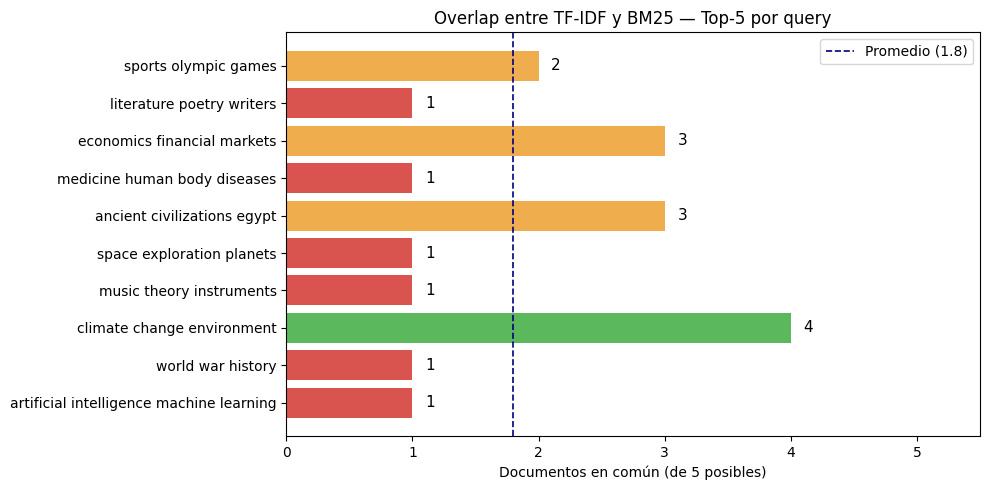

In [9]:
import matplotlib.pyplot as plt

# Calculamos overlap (documentos en común en el Top-5) por query
overlaps = []

for q in queries:
    titulos_tfidf = set(resultados_tfidf[q]["titulo"])
    titulos_bm25  = set(resultados_bm25[q]["titulo"])
    overlaps.append(len(titulos_tfidf & titulos_bm25))

# Imprimimos tabla resumen
print(f"{'Query':<45} {'Overlap':>7}")
print("-" * 54)
for q, ov in zip(queries, overlaps):
    print(f"{q:<45} {ov:>5}/5")
print("-" * 54)
print(f"{'Promedio':<45} {sum(overlaps)/len(overlaps):>5.2f}/5")

# Gráfico
fig, ax = plt.subplots(figsize=(10, 5))

colores = [
    "#d9534f" if ov <= 1 else "#f0ad4e" if ov <= 3 else "#5cb85c"
    for ov in overlaps
]

bars     = ax.barh(queries, overlaps, color=colores)
promedio = sum(overlaps) / len(overlaps)

ax.set_xlabel("Documentos en común (de 5 posibles)")
ax.set_title("Overlap entre TF-IDF y BM25 — Top-5 por query")
ax.set_xlim(0, 5.5)
ax.axvline(
    x=promedio, color="navy", linestyle="--",
    linewidth=1.2, label=f"Promedio ({promedio:.1f})"
)
ax.legend()

for bar, val in zip(bars, overlaps):
    ax.text(
        bar.get_width() + 0.1,
        bar.get_y() + bar.get_height() / 2,
        str(val), va="center", fontsize=11
    )

plt.tight_layout()
plt.show()